选择一个区域：5N-9N，245E-255E的空间区域，计算这个区域内的平均值，如果目标域与相邻天（从 -4 天到 + 4 天）相比经历了 Pr 异常的单个局部最大值（定义为第 0 天），则将其视为 CCKW 事件。

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# 配置参数
CACHE_DIR = "./cache/kelvin_wave/"
REGRESSION_CACHE_DIR = os.path.join(CACHE_DIR, "pr_regression_composite")
FIG_SAVE_DIR = "./figures/vertical_profile_composite/"

# 创建必要的目录
for d in [CACHE_DIR, REGRESSION_CACHE_DIR, FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)


EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Regression cache: {REGRESSION_CACHE_DIR}")
print(f"📁 Figure save directory: {FIG_SAVE_DIR}")
print("="*80)
print("="*80)
print("🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis")
print("="*80)
print(f"📅 Notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
def load_filtered_data(var_name, exp_list=None):
    """
    加载滤波后的数据
    
    Parameters:
    -----------
    var_name : str
        变量名称 ('pr', 'ua', 'va', 'omega')
    exp_list : list, optional
        实验列表
    
    Returns:
    --------
    data_dict : dict
        {exp_name: xr.DataArray}
    """
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    data_dict = {}
    
    # 定义可能的缓存目录（按优先级顺序）
    possible_dirs = [
        CACHE_DIR,                                    # ./cache/kelvin_wave/
        "./cache/kelvin_wave_3d/",                    # 3D变量目录
        os.path.join(CACHE_DIR, "../kelvin_wave_3d/") # 相对路径
    ]
    
    print(f"\n📂 Loading {var_name} data...")
    for exp in exp_list:
        loaded = False
        
        # 尝试在不同目录中查找文件
        for cache_dir in possible_dirs:
            cache_file = os.path.join(cache_dir, f'kelvin_{var_name}_{exp.lower()}.nc')
            
            if os.path.exists(cache_file):
                try:
                    data = xr.open_dataarray(cache_file)
                    
                    # 标准化维度名称：将 'level' 重命名为 'lev'（如果存在）
                    if 'level' in data.dims:
                        data = data.rename({'level': 'lev'})
                    
                    data_dict[exp] = data
                    file_size = os.path.getsize(cache_file) / (1024**2)
                    print(f"  ✅ {exp}: Loaded from {os.path.basename(cache_dir)}, "
                          f"Shape={data.shape}, Size={file_size:.1f}MB")
                    loaded = True
                    break
                except Exception as e:
                    print(f"  ❌ {exp}: Error loading from {cache_dir} - {str(e)}")
        
        if not loaded:
            print(f"  ⚠️  {exp}: Cache file not found in any directory!")
    
    return data_dict

print("✅ load_filtered_data 函数定义完成")

📁 Cache directory: ./cache/kelvin_wave/
📁 Regression cache: ./cache/kelvin_wave/pr_regression_composite
📁 Figure save directory: ./figures/vertical_profile_composite/
🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis
📅 Notebook started at: 2026-02-04 09:59:25
✅ load_filtered_data 函数定义完成


In [2]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')

if not pr_data_dict:
    print("❌ No precipitation data found! Please run the filtering step first.")
else:
    print(f"\n✅ Loaded {len(pr_data_dict)} experiments")


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments


In [3]:
# 创建colormap
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

### 6.1.6 垂直速度合成分析 (Wa/Omega Composite)

对垂直速度场进行合成分析，使用与降水和风场相同的事件时间

In [4]:
def load_detected_events(composite_dir=None, verbose=True):
    """
    加载已保存的事件检测结果
    
    Parameters:
    -----------
    composite_dir : str, optional
        事件数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    all_events : dict
        {exp_name: {'event_dates': [...], 'event_intensities': [...], 'n_events': ...}}
    success : bool
        是否成功加载
    """
    import json
    import os
    
    if composite_dir is None:
        composite_dir = os.path.join(os.getcwd(), 'composite_data')
    
    events_file = os.path.join(composite_dir, 'detected_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 Loading Detected Events")
        print("="*80)
        print(f"File: {events_file}")
        print()
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"⚠️  Event file not found: {events_file}")
            print("   Please run the event detection and save step first.")
        return None, False
    
    try:
        with open(events_file, 'r') as f:
            all_events = json.load(f)
        
        if verbose:
            print("✅ Event detection results loaded successfully!")
            print(f"\n📊 Events summary:")
            for exp, events_info in all_events.items():
                print(f"   {exp}: {events_info['n_events']} events")
                print(f"      Event dates range: {min(events_info['event_dates'])} to {max(events_info['event_dates'])}")
        
        return all_events, True
        
    except Exception as e:
        if verbose:
            print(f"❌ Failed to load events: {e}")
        return None, False

def compute_composite_with_std(data, event_dates, lags):
    """
    计算复合分析及其标准差（用于显著性检验）
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    """
    composites = []
    
    for event_idx in event_dates:
        if event_idx + min(lags) < 0 or event_idx + max(lags) >= len(data.time):
            continue
        
        event_composite = []
        for lag in lags:
            event_composite.append(data.isel(time=event_idx + lag))
        
        event_composite = xr.concat(event_composite, dim='lag')
        composites.append(event_composite)
    
    if len(composites) > 0:
        # 沿事件维度堆叠
        all_composites = xr.concat(composites, dim='event')
        
        # 计算平均和标准差
        composite_mean = all_composites.mean(dim='event')
        composite_std = all_composites.std(dim='event')
        
        composite_mean['lag'] = list(lags)
        composite_std['lag'] = list(lags)
        
        n_events = len(composites)
    else:
        composite_mean = None
        composite_std = None
        n_events = 0
    
    return composite_mean, composite_std, n_events


print("✅ Composite analysis functions defined")    

def apply_composite_to_other_variable(variable_data, event_dates, lags, 
                                     exp_name='', verbose=True):
    """
    使用已检测到的事件，对其他变量进行超前滞后合成分析
    
    Parameters:
    -----------
    variable_data : xr.DataArray
        要进行合成分析的变量数据 (time, lat, lon) 或 (time, lev, lat, lon)
    event_dates : list of int
        从降水分析中获得的事件时间索引
    lags : range or list
        lag 天数，应该与降水合成使用相同的范围
    exp_name : str
        实验名称（用于输出）
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    
    Example:
    --------
    # 加载事件信息
    all_events, success = load_detected_events()
    
    # 加载潜热通量数据
    lhf_data = xr.open_dataarray('latent_heat_flux_cntl.nc')
    
    # 使用降水事件对潜热通量进行合成
    lhf_composite, lhf_std, n = apply_composite_to_other_variable(
        lhf_data, 
        all_events['CNTL']['event_dates'], 
        range(-4, 5),
        exp_name='CNTL'
    )
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"🔄 Computing composite for {exp_name}")
        print(f"{'='*70}")
        print(f"   Variable shape: {variable_data.shape}")
        print(f"   Number of events: {len(event_dates)}")
        print(f"   Lag range: {min(lags)} to {max(lags)} days")
    
    # 使用已有的合成函数
    composite_mean, composite_std, n_events = compute_composite_with_std(
        data=variable_data,
        event_dates=event_dates,
        lags=lags
    )
    
    if verbose:
        if composite_mean is not None:
            print(f"✅ Composite computed successfully")
            print(f"   Valid events used: {n_events}")
            print(f"   Composite shape: {composite_mean.shape}")
            print(f"   Value range: [{composite_mean.min().values:.4e}, {composite_mean.max().values:.4e}]")
        else:
            print(f"❌ Failed to compute composite")
        print(f"{'='*70}")
    
    return composite_mean, composite_std, n_events



✅ Composite analysis functions defined


In [5]:
wa_data_dict = load_filtered_data('omega')
pr_data_dict = load_filtered_data('pr')


📂 Loading omega data...
  ✅ CNTL: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ P4K: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ 4CO2: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB


In [6]:
pr_composites_dict = {}
pr_std_dict = {}
all_events, success = load_detected_events()    
for exp in EXPERIMENTS:
    pr_composite, pr_std, n_events = compute_composite_with_std(
        data=pr_data_dict[exp],
        event_dates=all_events[exp]['event_dates'],
        lags=range(-4, 5)
    )
    pr_composites_dict[exp] = pr_composite
    pr_std_dict[exp] = pr_std
    print(f"✅ {exp} precipitation composite computed with {n_events} events")


📂 Loading Detected Events
File: /work/mh1498/m301257/composite_data/detected_events.json

✅ Event detection results loaded successfully!

📊 Events summary:
   CNTL: 546 events
      Event dates range: 19 to 5095
   P4K: 548 events
      Event dates range: 12 to 5090
   4CO2: 552 events
      Event dates range: 10 to 5100
✅ CNTL precipitation composite computed with 546 events
✅ CNTL precipitation composite computed with 546 events
✅ P4K precipitation composite computed with 548 events
✅ P4K precipitation composite computed with 548 events
✅ 4CO2 precipitation composite computed with 552 events
✅ 4CO2 precipitation composite computed with 552 events


In [7]:
try:
    all_events, success = load_detected_events()
    test_wa = wa_data_dict['CNTL']
    print("✅ Omega vertical velocity data loaded, computing composites...")
    wa_composite_dict = {}
    for exp in ['CNTL', 'P4K', '4CO2']:
        wa_composite, _, _ = apply_composite_to_other_variable(
            wa_data_dict[exp],
            all_events[exp]['event_dates'],
            range(-4, 5),
            exp_name=exp,
            verbose=False
        )
        wa_composite_dict[exp] = wa_composite
        print(f"   ✅ {exp} composite computed")
except:
    print("⚠️  Omega vertical velocity data not loaded, please run: wa_data_dict = load_filtered_data('omega')")


📂 Loading Detected Events
File: /work/mh1498/m301257/composite_data/detected_events.json

✅ Event detection results loaded successfully!

📊 Events summary:
   CNTL: 546 events
      Event dates range: 19 to 5095
   P4K: 548 events
      Event dates range: 12 to 5090
   4CO2: 552 events
      Event dates range: 10 to 5100
✅ Omega vertical velocity data loaded, computing composites...
   ✅ CNTL composite computed
   ✅ CNTL composite computed
   ✅ P4K composite computed
   ✅ P4K composite computed
   ✅ 4CO2 composite computed
   ✅ 4CO2 composite computed



🎨 Plotting improved spatial composite maps...
💾 Figure saved: ./figures/vertical_profile_composite/composite_spatial_maps_3x2_improved.png
💾 Figure saved: ./figures/vertical_profile_composite/composite_spatial_maps_3x2_improved.png


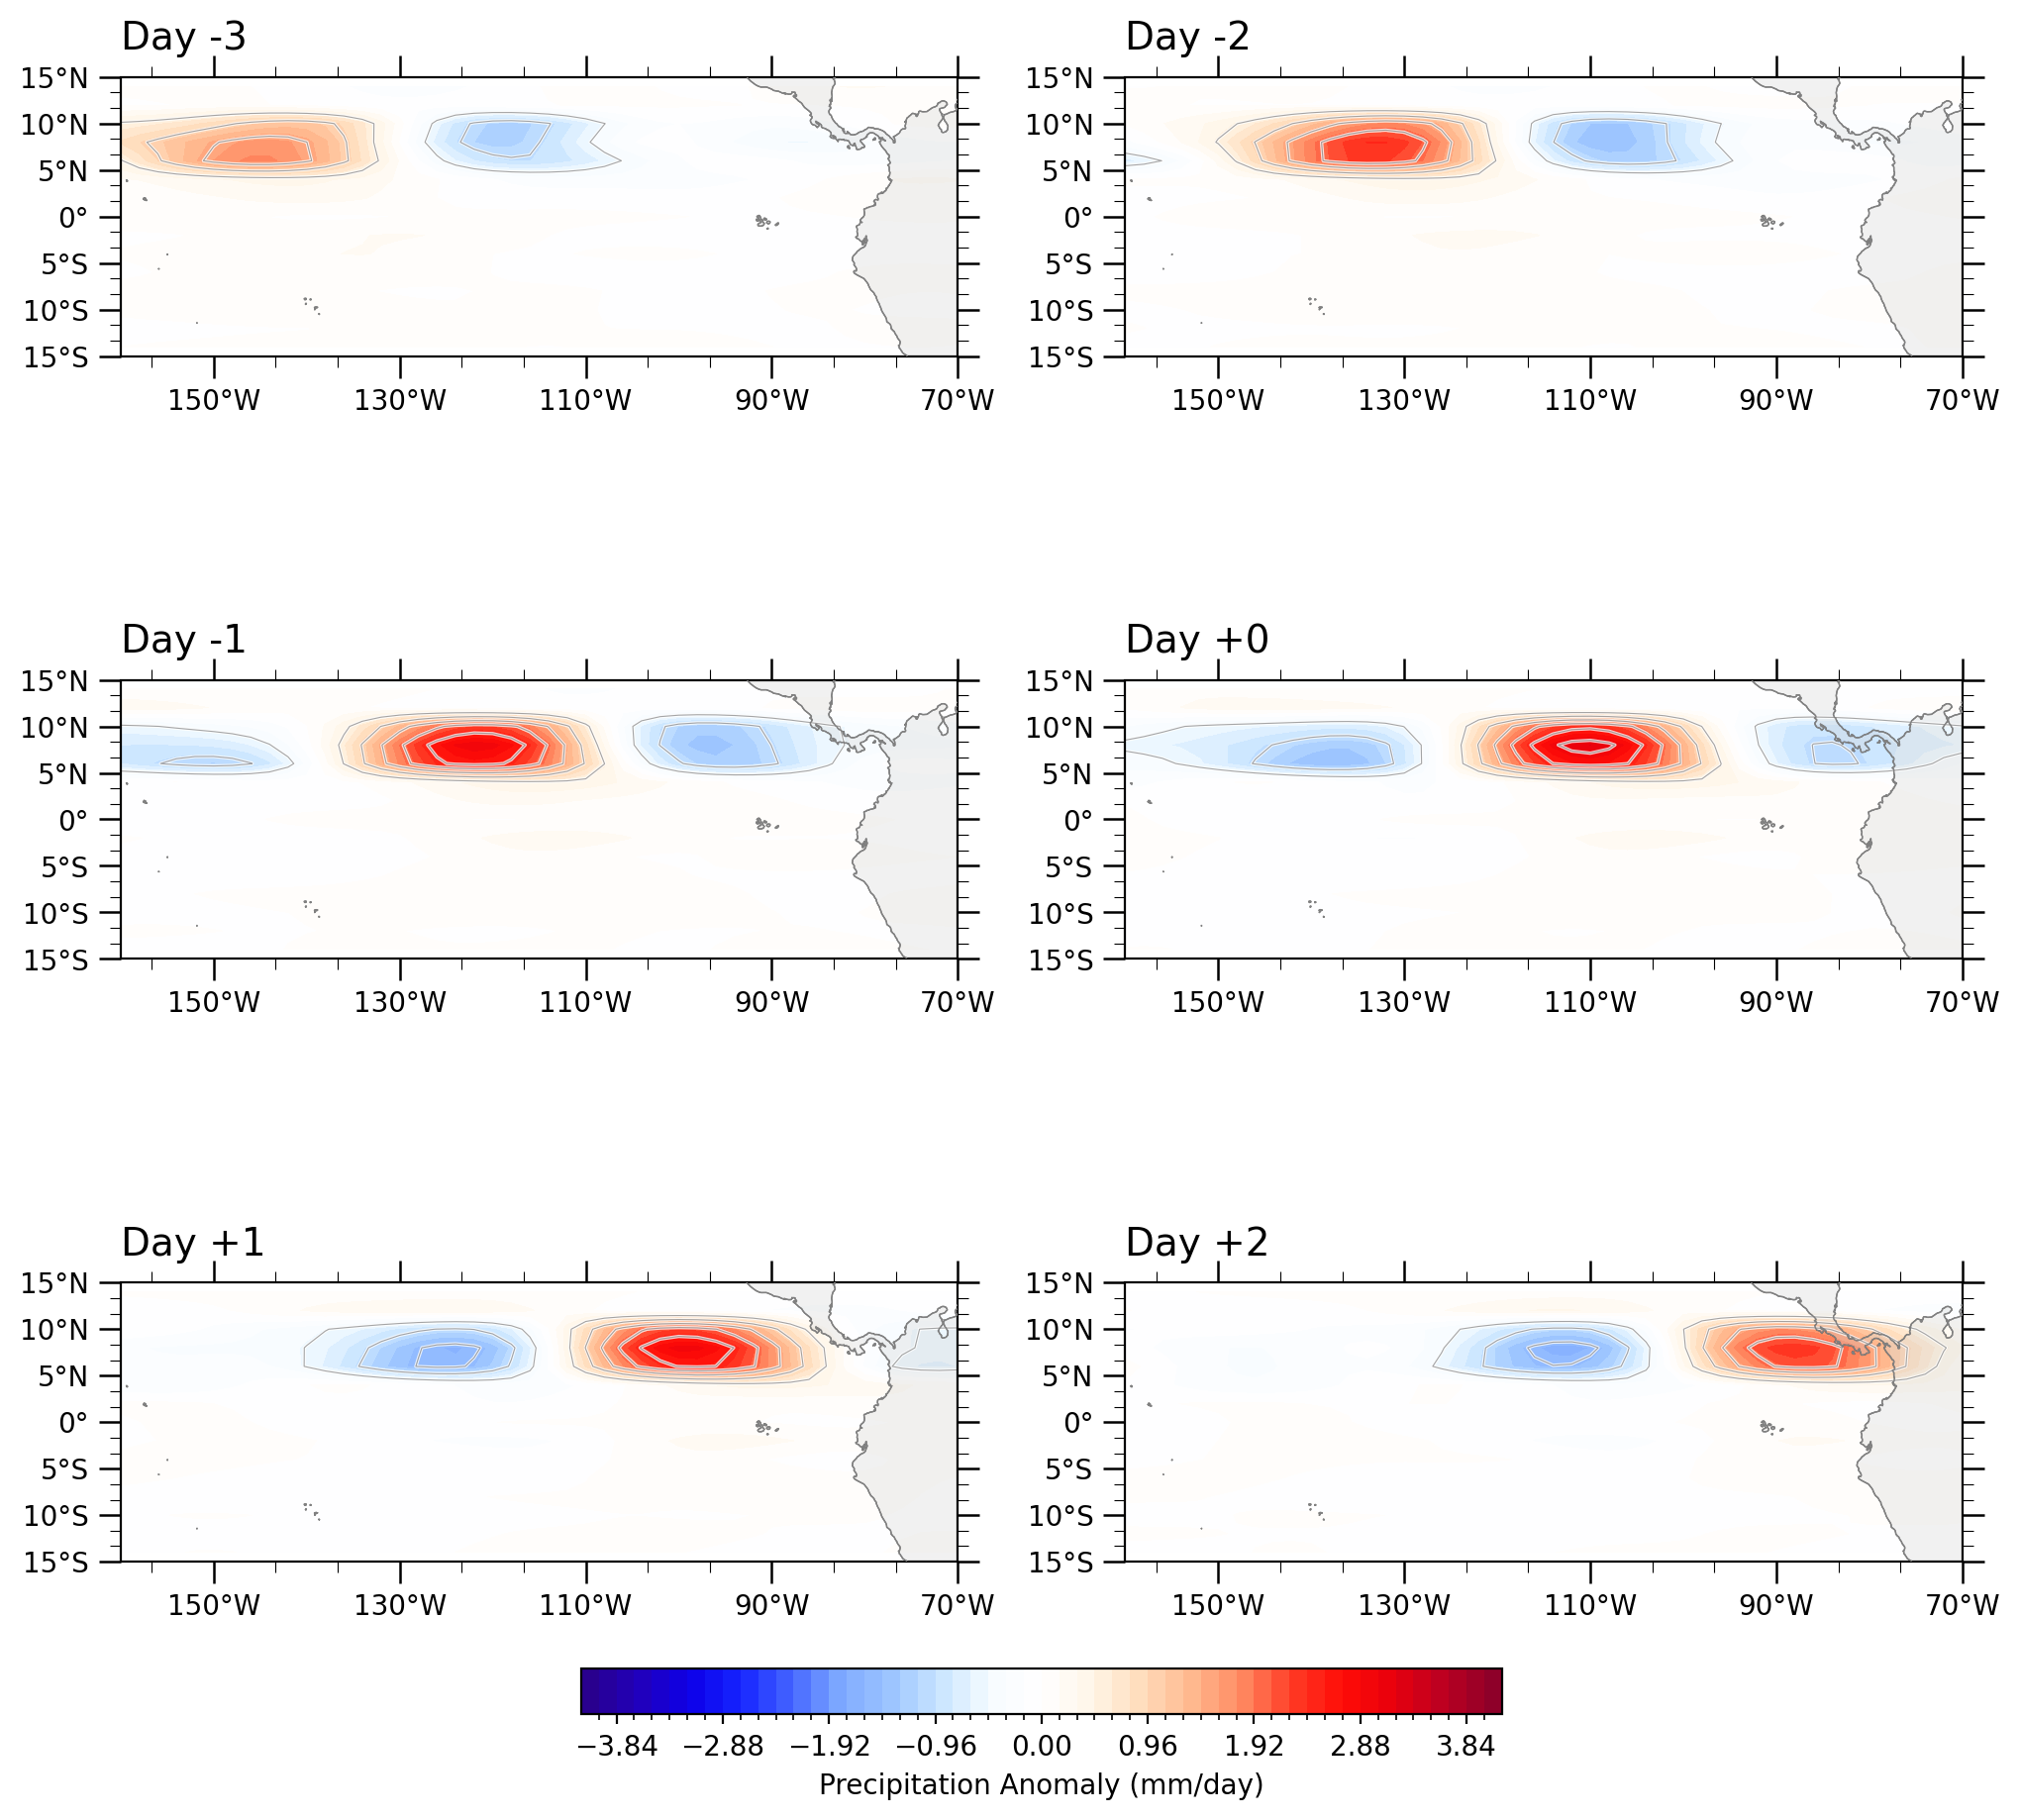

In [8]:
def plot_spatial_composite_3x2(composite, lag_days=[-3, -2, -1, 0, 1, 2],
                              figsize=(12, 14), vmin=-2.0, vmax=2.0):
    """
    绘制单实验的空间分布图，固定 3x2 布局
    使用改进的配色方案和样式
    """
    import matplotlib.patheffects as PathEffects
    try:
        import geocat.viz.util as gvutil
        use_geocat = True
    except ImportError:
        print("⚠️  geocat-viz not available, using basic style")
        use_geocat = False

    nrows, ncols = 3, 2
    total_panels = nrows * ncols

    # 使用中心经度210°的投影
    proj = ccrs.PlateCarree(central_longitude=210)
    fig = plt.figure(figsize=figsize, dpi=200)
    
    # 创建自定义colormap（使用连续插值而不是固定颜色列表）
    newcmp = cmaps.NCV_blu_red
    
    from matplotlib.colors import LinearSegmentedColormap
    # 从 NCV_blu_red 创建连续的 colormap
    colors_blue = [newcmp[i].colors for i in [5, 20, 35, 50, 65, 85, 95, 110, 125]]
    colors_red = [newcmp[i].colors for i in [135, 150, 165, 180, 200, 210, 220, 235, 250]]
    
    # 创建颜色节点：蓝色 -> 白色 -> 红色
    all_colors = colors_blue + [[1., 1., 1.]] + colors_red
    n_colors = len(all_colors)
    color_positions = np.linspace(0, 1, n_colors)
    
    # 创建连续的 colormap
    custom_cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', 
                                                     list(zip(color_positions, all_colors)),
                                                     N=256)
    
    # 设置填色图参数（增加层级数使颜色过渡更平滑）
    levels_fill = np.linspace(vmin, vmax, 51)  # 从21增加到51
    
    # 设置等值线参数（更细更柔和）
    delc = 0.5
    levels_contour = np.arange(-10, 0, delc)
    levels_contour = np.append(levels_contour, np.arange(delc, 10, delc))
    
    ax_list = []
    
    for idx in range(total_panels):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)
        ax_list.append(ax)
        
        if idx < len(lag_days):
            lag = lag_days[idx]
            data_lag = composite.sel(lag=lag)
            
            # 添加循环经度以避免间隙
            if use_geocat:
                data_lag = gvutil.xr_add_cyclic_longitudes(data_lag, 'lon')
            
            # 添加海岸线
            ax.coastlines(linewidth=0.5, alpha=0.6)
            
            # 设置坐标范围和刻度 (150°E - 250°E)
            # 由于 central_longitude=210, 150°E对应-60°, 250°E对应+40°
            if use_geocat:
                gvutil.set_axes_limits_and_ticks(ax,
                                               xlim=(-10, 80),
                                               ylim=(-15, 15),
                                               xticks=np.arange(-40, 91, 20),
                                               yticks=np.arange(-15, 16, 5))
                gvutil.add_major_minor_ticks(ax, labelsize=10)
                gvutil.add_lat_lon_ticklabels(ax)
            else:
                ax.set_xlim([-60, 40])
                ax.set_ylim([-15, 15])
                ax.set_xticks(np.arange(-60, 41, 20))
                ax.set_yticks(np.arange(-15, 16, 5))
                ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
                ax.yaxis.set_major_formatter(LatitudeFormatter())
            
            # 绘制填色图
            cf = data_lag.plot.contourf(
                ax=ax,
                levels=levels_fill,
                cmap=custom_cmap,  # 使用连续的 colormap
                add_colorbar=False,
                transform=ccrs.PlateCarree(),
                extend='both',
                add_labels=False 
            )
            
            # 添加陆地和海岸线
            ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2, alpha=0.3)
            ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=3)
            
            # 绘制等值线（更细更柔和的样式）
            contour = data_lag.plot.contour(
                ax=ax,
                levels=levels_contour,
                colors='dimgray',  # 使用更柔和的灰色
                alpha=0.6,  # 降低透明度使其更柔和
                linewidths=0.4,  # 稍微增加线宽但保持细腻
                linestyles='solid',
                add_labels=False,
                transform=ccrs.PlateCarree()
            )
            
            # 添加柔和的白色边缘效果
            try:
                pe = [PathEffects.withStroke(linewidth=1.2, foreground="white", alpha=0.8)]
                if hasattr(contour, 'collections'):
                    for collection in contour.collections:
                        collection.set_path_effects(pe)
                else:
                    # xarray返回的contour对象本身就是collection
                    plt.setp(contour.collections if hasattr(contour, 'collections') else [contour], 
                            path_effects=pe)
            except:
                pass  # 如果设置失败，继续
            
            # 设置标题
            if use_geocat:
                gvutil.set_titles_and_labels(ax,
                                           lefttitle=f'Day {lag:+d}',
                                           lefttitlefontsize=14,
                                           righttitle='',
                                           xlabel="",
                                           ylabel="")
            else:
                ax.set_title(f'Day {lag:+d}', fontsize=14, loc='left')
        
        else:
            # 空白面板
            ax.axis("off")
    
    # 添加颜色棒（更平滑，不显示边缘线）
    fig.colorbar(cf, ax=ax_list,
                 drawedges=False,  # 去掉边缘线使colorbar更平滑
                 orientation='horizontal',
                 shrink=0.5,
                 pad=0.05,
                 extendfrac='auto',
                 extendrect=True,
                 label='Precipitation Anomaly (mm/day)')
    
  
    
    save_path = os.path.join(FIG_SAVE_DIR, "composite_spatial_maps_3x2_improved.png")
    # plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"💾 Figure saved: {save_path}")

    return fig

# 绘制改进样式的空间分布图
print("\n🎨 Plotting improved spatial composite maps...")
fig_spatial = plot_spatial_composite_3x2(
    pr_composites_dict['CNTL'],   # 单个实验
    lag_days=[-3, -2, -1, 0, 1, 2],
    vmin=-4.0,
    vmax=4.0
)
plt.show()


6.2 垂直剖面分析

在 Day 0 的 110°W (250°E) 附近找到降水最大值位置，然后提取该位置在所有超前滞后天的垂直速度剖面

6.2.1 加载位势高度数据

In [21]:
# 1. 加载 zg 数据（位势高度，单位：m）
print("读取 zg 数据...")
zg_cntl = xr.open_dataset('processed_data/zg_2deg_interp_cntl.nc')['zg']
zg_p4k = xr.open_dataset('processed_data/zg_2deg_interp_p4k.nc')['zg']
zg_4co2 = xr.open_dataset('processed_data/zg_2deg_interp_4co2.nc')['zg']

# 2. 检查维度名称并标准化
print(f"  zg_cntl dimensions: {zg_cntl.dims}")
if 'level_full' in zg_cntl.dims:
    zg_cntl = zg_cntl.rename({'level_full': 'lev'})
    zg_p4k = zg_p4k.rename({'level_full': 'lev'})
    zg_4co2 = zg_4co2.rename({'level_full': 'lev'})
    print("  ✓ 维度 'level_full' 已重命名为 'lev'")

# 3. 创建海洋 mask（如果还没有的话）
try:
    # 尝试使用已有的 ocean_mask
    test_mask = ocean_mask
    print("✓ 使用已有的 ocean_mask")
except NameError:
    # 如果不存在，创建一个简单的海洋 mask（全部为True，即所有点都计算）
    print("创建海洋 mask...")
    ocean_mask = xr.ones_like(zg_cntl.isel(lev=0, drop=True))
    print("✓ 海洋 mask 创建完成")

# 4. 应用海洋 mask
zg_cntl_ocean = zg_cntl.where(ocean_mask)
zg_p4k_ocean = zg_p4k.where(ocean_mask)
zg_4co2_ocean = zg_4co2.where(ocean_mask)

# 5. 计算海洋平均高度（对每一层）
# zg 不随时间变化，所以只对空间平均
zg_cntl_mean = zg_cntl_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_p4k_mean = zg_p4k_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_4co2_mean = zg_4co2_ocean.mean(dim=['lat', 'lon'], skipna=True)

# 6. 转换为 km 单位
zg_cntl_km = zg_cntl_mean / 1000.0
zg_p4k_km = zg_p4k_mean / 1000.0
zg_4co2_km = zg_4co2_mean / 1000.0

# 7. 创建高度字典
zg_dict = {
    'CNTL': zg_cntl_km,
    'P4K': zg_p4k_km,
    '4CO2': zg_4co2_km
}

print(f"\n✓ zg 数据加载完成")
print(f"  高度范围: {zg_cntl_km.min().values:.2f} - {zg_cntl_km.max().values:.2f} km")
print(f"  层数: {len(zg_cntl_km)}")
print(f"  维度: {zg_cntl_km.dims}")

读取 zg 数据...
  zg_cntl dimensions: ('level_full', 'lat', 'lon')
  ✓ 维度 'level_full' 已重命名为 'lev'
✓ 使用已有的 ocean_mask

✓ zg 数据加载完成
  高度范围: 0.13 - 22.86 km
  层数: 22
  维度: ('lev',)


6.2.2 定义垂直剖面提取函数

In [22]:
def find_pr_max_location_at_110W(pr_composite, target_lon=250.0, lon_range=10.0, lat_range=(5, 15)):
    """
    在 Day 0 的 110°W (250°E) 附近找到降水最大值的位置
    
    Parameters:
    -----------
    pr_composite : xr.DataArray
        降水合成场，包含 lag, lat, lon 维度
    target_lon : float
        目标经度 (110°W = 250°E)
    lon_range : float
        搜索的经度范围 (±度)
    lat_range : tuple
        搜索的纬度范围
    
    Returns:
    --------
    max_lat : float
        最大值所在纬度
    max_lon : float
        最大值所在经度
    max_value : float
        最大降水值
    """
    # 选择 Day 0
    pr_day0 = pr_composite.sel(lag=0)
    
    # 选择经度和纬度范围
    lon_min = target_lon - lon_range
    lon_max = target_lon + lon_range
    lat_min, lat_max = lat_range
    
    pr_subset = pr_day0.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_min, lat_max)
    )
    
    # 找到最大值位置
    max_idx = pr_subset.argmax(dim=['lat', 'lon'])
    max_lat = pr_subset.lat[max_idx['lat']].values
    max_lon = pr_subset.lon[max_idx['lon']].values
    max_value = pr_subset.max().values
    
    print(f"📍 Maximum precipitation location on Day 0:")
    print(f"   Longitude: {max_lon:.2f}°E ({360-max_lon:.2f}°W)")
    print(f"   Latitude: {max_lat:.2f}°N")
    print(f"   Value: {max_value:.3f} mm/day")
    
    return max_lat, max_lon, max_value


def extract_vertical_profile_at_location(wa_composite, lat, lon, tolerance=2.0):
    """
    在指定位置提取垂直速度的时间-高度剖面
    
    Parameters:
    -----------
    wa_composite : xr.DataArray
        垂直速度合成场 (lag, lev, lat, lon)
    lat : float
        目标纬度
    lon : float
        目标经度
    tolerance : float
        选择最近点的容忍度（度）
    
    Returns:
    --------
    profile : xr.DataArray
        垂直剖面 (lag, lev)
    """
    # 选择最接近的经纬度点
    profile = wa_composite.sel(
        lat=lat,
        lon=lon,
        method='nearest',
        tolerance=tolerance
    )
    
    actual_lat = profile.lat.values
    actual_lon = profile.lon.values
    
    print(f"   Selected grid point: {actual_lon:.2f}°E, {actual_lat:.2f}°N")
    
    return profile


print("✅ Vertical profile extraction functions defined")

✅ Vertical profile extraction functions defined


6.2.3 提取最大降水位置

In [23]:
# 为每个实验找到 Day 0 在 110°W 附近的最大降水位置
print("\n" + "="*80)
print("🔍 Finding maximum precipitation locations at 110°W on Day 0")
print("="*80)

max_locations = {}

for exp in EXPERIMENTS:
    print(f"\n{exp}:")
    max_lat, max_lon, max_val = find_pr_max_location_at_110W(
        pr_composites_dict[exp],
        target_lon=250.0,  # 110°W = 250°E
        lon_range=10.0,
        lat_range=(5, 15)
    )
    max_locations[exp] = {
        'lat': max_lat,
        'lon': max_lon,
        'value': max_val
    }


🔍 Finding maximum precipitation locations at 110°W on Day 0

CNTL:
📍 Maximum precipitation location on Day 0:
   Longitude: 250.00°E (110.00°W)
   Latitude: 8.00°N
   Value: 3.201 mm/day

P4K:
📍 Maximum precipitation location on Day 0:
   Longitude: 250.00°E (110.00°W)
   Latitude: 8.00°N
   Value: 3.915 mm/day

4CO2:
📍 Maximum precipitation location on Day 0:
   Longitude: 250.00°E (110.00°W)
   Latitude: 8.00°N
   Value: 3.212 mm/day


6.2.4 提取垂直剖面数据

In [24]:
# 提取每个实验在对应位置的垂直剖面
print("\n" + "="*80)
print("📊 Extracting vertical profiles at maximum locations")
print("="*80)

wa_profiles = {}

for exp in EXPERIMENTS:
    print(f"\n{exp}:")
    profile = extract_vertical_profile_at_location(
        wa_composite_dict[exp],
        lat=max_locations[exp]['lat'],
        lon=max_locations[exp]['lon'],
        tolerance=2.0
    )
    wa_profiles[exp] = profile
    print(f"   Profile shape: {profile.shape}")
    print(f"   Lag range: {profile.lag.values}")
    print(f"   Level range: {profile.lev.values.min():.1f} - {profile.lev.values.max():.1f} hPa")
    
print("\n✅ All vertical profiles extracted")


📊 Extracting vertical profiles at maximum locations

CNTL:
   Selected grid point: 250.00°E, 8.00°N
   Profile shape: (9, 22)
   Lag range: [-4 -3 -2 -1  0  1  2  3  4]
   Level range: 31.0 - 90.0 hPa

P4K:
   Selected grid point: 250.00°E, 8.00°N
   Profile shape: (9, 22)
   Lag range: [-4 -3 -2 -1  0  1  2  3  4]
   Level range: 31.0 - 90.0 hPa

4CO2:
   Selected grid point: 250.00°E, 8.00°N
   Profile shape: (9, 22)
   Lag range: [-4 -3 -2 -1  0  1  2  3  4]
   Level range: 31.0 - 90.0 hPa

✅ All vertical profiles extracted


6.2.5 绘制垂直剖面图（高度坐标）


🎨 绘制垂直剖面对比图（高度坐标）
✅ 高度坐标绘图函数定义完成

💾 图形已保存: ./figures/vertical_profile_composite/wa_vertical_profile_height_comparison.png

💾 图形已保存: ./figures/vertical_profile_composite/wa_vertical_profile_height_comparison.png


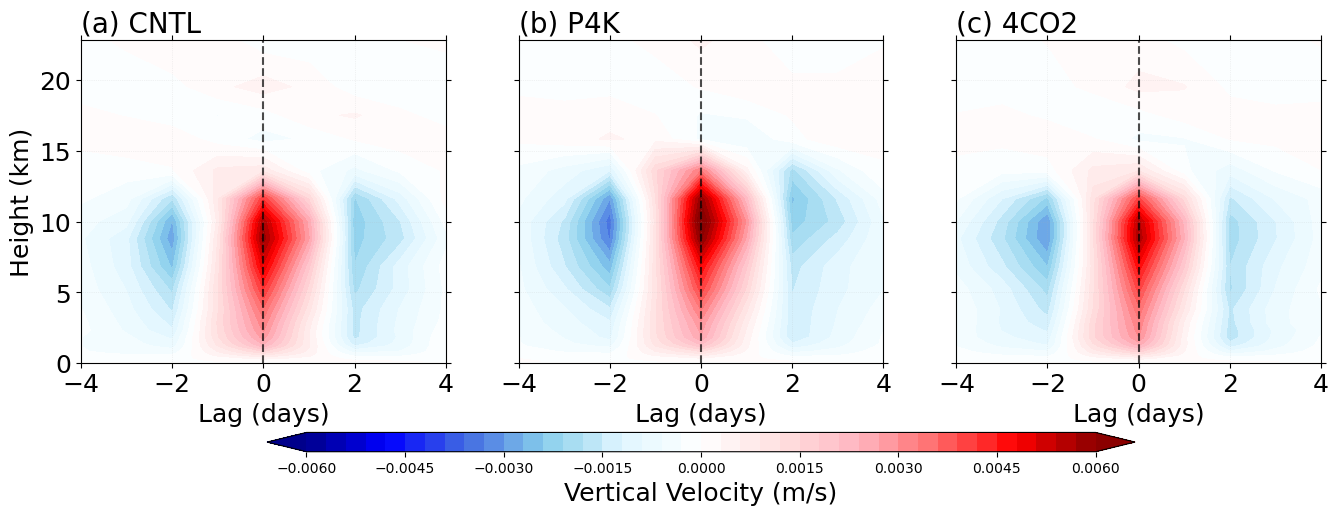

In [41]:
# 绘制垂直剖面对比图（使用高度坐标）
print("\n" + "="*80)
print("🎨 绘制垂直剖面对比图（高度坐标）")
print("="*80)
def plot_wa_vertical_profile_height(wa_profiles_dict, zg_dict, max_locations_dict, 
                                     figsize=(16, 6)):
    """
    绘制多个实验的垂直速度时间-高度剖面对比图（使用高度坐标）
    
    Parameters:
    -----------
    wa_profiles_dict : dict
        {exp_name: xr.DataArray (lag, lev)} - 垂直速度剖面，单位 m/s
    zg_dict : dict
        {exp_name: xr.DataArray (lev)} - 位势高度，单位 km
    max_locations_dict : dict
        {exp_name: {'lat': float, 'lon': float, 'value': float}}
    figsize : tuple
        图形尺寸
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    """
    n_exp = len(wa_profiles_dict)
    fig, axes = plt.subplots(1, n_exp, figsize=figsize, sharey=True)
    
    if n_exp == 1:
        axes = [axes]
    
    # 设置colormap（蓝色=上升，红色=下沉）
    from matplotlib.colors import LinearSegmentedColormap
    colors_list = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
                   '#FFFFFF', 
                   '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    cmap = LinearSegmentedColormap.from_list('wa_cmap', colors_list, N=256)
    
    # 计算全局范围（用于统一colorbar）
    all_data = [profile.values for profile in wa_profiles_dict.values()]
  
    
    # 设置填色等级
    levels = np.linspace(-0.006,0.006,41)
    for idx, (exp, profile) in enumerate(wa_profiles_dict.items()):
        ax = axes[idx]
        
        # 获取数据
        lag_vals = profile.lag.values
        height_km = zg_dict[exp].values  # 高度 (km)
        data = profile.values  # wa (m/s)
        
        # 创建网格
        LAG, HEIGHT = np.meshgrid(lag_vals, height_km)
        
        # 绘制填色图
        cf = ax.contourf(LAG, HEIGHT, data.T, levels=levels, 
                        cmap=cmap, extend='both')
        
        # 绘制等值线（根据实际数值范围调整）
        contour_levels = np.arange(-0.1, 0, 0.01)
        contour_levels = np.append(contour_levels, np.arange(0.01, 0.1, 0.01))
        cs = ax.contour(LAG, HEIGHT, data.T, levels=contour_levels,
                       colors='dimgray', linewidths=0.5, alpha=0.6)
        
        # 在 Day 0 处添加垂直虚线
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        
        # 设置坐标轴
        ax.set_ylim([0, height_km.max()])  # 从地面到最高层
        ax.set_xlim([lag_vals.min(), lag_vals.max()])
        ax.set_xticks(lag_vals[::2])  # 每隔一天显示
        
        # 设置标签
        ax.set_xlabel('Lag (days)', fontsize=18)
        if idx == 0:
            ax.set_ylabel('Height (km)', fontsize=18)
        
        # 设置标题
        loc_info = max_locations_dict[exp]
        title = f"({chr(97 + idx)}) {exp}"
        ax.set_title(title, fontsize=20,loc='left')
        
        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        ax.tick_params(labelsize=18, which='both', top=True, right=True)
    # 添加colorbar
    cbar = fig.colorbar(cf, ax=axes, orientation='horizontal', 
                       pad=0.15, shrink=0.7, aspect=45)
    cbar.set_label('Vertical Velocity (m/s)', fontsize=18)
    

    
    return fig

print("✅ 高度坐标绘图函数定义完成")
fig_height = plot_wa_vertical_profile_height(
    wa_profiles,
    zg_dict,
    max_locations,
    figsize=(16, 6)
)

# 保存图形
save_path = os.path.join(FIG_SAVE_DIR, "wa_vertical_profile_height_comparison.png")
fig_height.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n💾 图形已保存: {save_path}")

plt.show()

6.2.6 绘制垂直廓线图（线图形式）

✅ 线图绘制函数定义完成

🎨 绘制线图形式的垂直廓线...
💾 图形已保存: ./figures/vertical_profile_composite/wa_vertical_line_profiles_height.png
💾 图形已保存: ./figures/vertical_profile_composite/wa_vertical_line_profiles_height.png


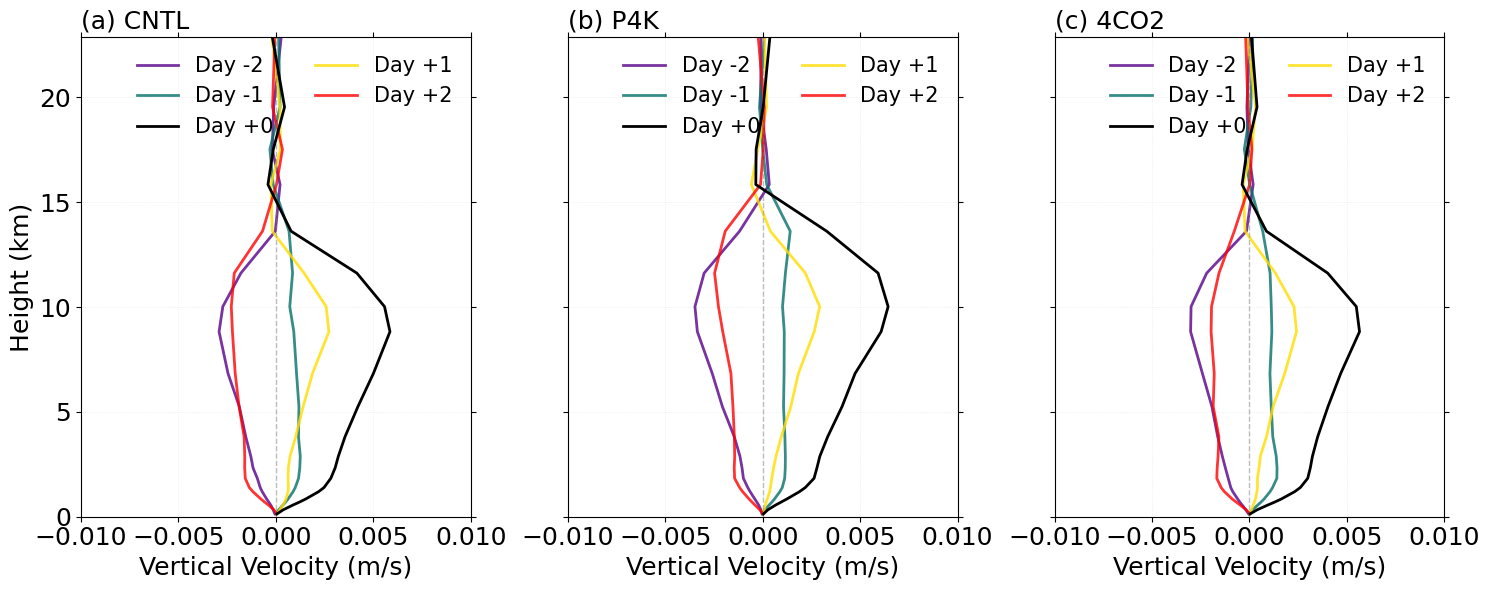

In [62]:
def plot_wa_line_profiles_height(wa_profiles_dict, zg_dict, 
                                 selected_lags=[-3, -2, -1, 0, 1, 2, 3],
                                 figsize=(16, 6)):
    """
    绘制不同lag天的垂直廓线对比（线图形式，使用高度坐标）
    
    Parameters:
    -----------
    wa_profiles_dict : dict
        {exp_name: xr.DataArray (lag, lev)} - 垂直速度，单位 m/s
    zg_dict : dict
        {exp_name: xr.DataArray (lev)} - 位势高度，单位 km
    selected_lags : list
        要绘制的lag天数
    figsize : tuple
        图形尺寸
    """
    n_exp = len(wa_profiles_dict)
    fig, axes = plt.subplots(1, n_exp, figsize=figsize, sharey=True)
    
    if n_exp == 1:
        axes = [axes]
    
    # 设置颜色映射
    colors = cmaps.ViBlGrWhYeOrRe(np.linspace(0, 1, len(selected_lags)))
    
    for idx, (exp, profile) in enumerate(wa_profiles_dict.items()):
        ax = axes[idx]
        
        height_km = zg_dict[exp].values
        
        # 绘制不同lag天的廓线
        for i, lag in enumerate(selected_lags):
            if lag in profile.lag.values:
                data = profile.sel(lag=lag).values  # m/s
                
                # Day 0 用粗线
                if lag == 0:
                    ax.plot(data, height_km, color='black', linewidth=2,
                           label=f'Day {lag:+d}', zorder=10)
                else:
                    ax.plot(data, height_km, color=colors[i], linewidth=2,
                           label=f'Day {lag:+d}', alpha=0.8)
        
        # 添加零线
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        # 设置坐标轴
        ax.set_ylim([0, height_km.max()])
        
        ax.set_xlabel('Vertical Velocity (m/s)', fontsize=18)
        if idx == 0:
            ax.set_ylabel('Height (km)', fontsize=18)
        
        ax.set_title(f"({chr(97 + idx)}) {exp}", fontsize=18, loc='left')
        ax.legend(loc='best', fontsize=15, ncol=2,frameon=False)
        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        ax.tick_params(labelsize=18, which='both', top=True, right=True)
        ax.set_xlim(-0.01,0.01)
    plt.tight_layout()
    
    return fig

print("✅ 线图绘制函数定义完成")
# 绘制线图形式的垂直廓线
print("\n🎨 绘制线图形式的垂直廓线...")
fig_lines_height = plot_wa_line_profiles_height(
    wa_profiles,
    zg_dict,
    selected_lags=[ -2, -1, 0, 1, 2],
    figsize=(15, 6)
)

save_path = os.path.join(FIG_SAVE_DIR, "wa_vertical_line_profiles_height.png")
fig_lines_height.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"💾 图形已保存: {save_path}")

plt.show()

6.2.7 分析总结

上面的图展示了：

1. **时间-高度剖面图（填色图）**：展示了 wa（垂直速度）在 Day 0 最大降水位置的演变
   - 横轴：超前滞后天数（-4 到 +4 天）
   - 纵轴：高度（单位：km）
   - 蓝色区域：上升运动（wa > 0，向上）
   - 红色区域：下沉运动（wa < 0，向下）
   - 单位：m/s

2. **垂直廓线图（线图）**：对比不同天次的垂直结构
   - 黑色粗线：Day 0（降水最大值日）
   - 彩色线：其他超前滞后天
   - 可以清晰看到上升运动的垂直结构演变

3. **三个实验对比**：CNTL、P4K、4CO2
   - 可以观察气候变化（增温、CO2增加）对 Kelvin 波垂直结构的影响
   - 使用位势高度（zg）将气压层转换为实际高度